In [48]:
from openmm import app, unit
import openmm

from rdkit import Chem
from rdkit.Chem import AllChem

from openff.toolkit import Molecule
from openmmforcefields.generators import GAFFTemplateGenerator

import requests
import numpy as np
import matplotlib.pyplot as plt

from tqdm.notebook import tqdm
from scipy.special import logsumexp
from seaborn import kdeplot


In [134]:
# from:
# Revealing Atropisomer Axial Chirality in Drug Discovery
smiles = 'C1C=CC2C=CC(C=O)=C(C(=O)N(C(C)C)C(C)C)C=2C=1'
mol = Chem.AddHs(Chem.MolFromSmiles(smiles))
AllChem.EmbedMolecule(mol)

0

In [135]:
offmol = Molecule.from_rdkit(mol)

response = requests.post('http://localhost:5000/process', json={'input': Chem.MolToMolBlock(mol)})
partial_charges = np.array(response.json())
offmol.partial_charges = partial_charges*unit.elementary_charge

offtop = offmol.to_topology().to_openmm()
offpos = offmol.conformers[0].to_openmm()

In [181]:
gen = GAFFTemplateGenerator(molecules=offmol)
ff = app.ForceField('implicit/gbn2.xml')
ff.registerTemplateGenerator(gen.generator)

# possibly 
system = ff.createSystem(
    offtop,
    constraints=app.HBonds
    #hydrogenMass=3*unit.amu
)

simbo = app.Simulation(
    offtop,
    system, 
    openmm.LangevinMiddleIntegrator(298, 1, 2*unit.femtosecond),
)
simbo.context.setPositions(
    offpos
)

simbo.minimizeEnergy()

st = app.SimulatedTempering(
    simbo, 
    tempChangeInterval=25,
    numTemperatures=15, 
    minTemperature=298*unit.kelvin, 
    maxTemperature=1500*unit.kelvin,
    reportFile=open('./st.dat', 'w')
)


In [183]:
while st._weightUpdateFactor>0.0005:
    st.step(1000)
    print(st._weightUpdateFactor, st._histogram)
    nrg = st.simulation.context.getState(getEnergy=True).getPotentialEnergy()
    if np.isnan(nrg._value):
        print("NAN")
        break

1.0 [7, 6, 4, 2, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 2, 4, 5, 5]
1.0 [7, 6, 4, 2, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 6, 8, 11, 15, 16]
1.0 [7, 6, 4, 2, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 5, 8, 11, 14, 17, 20, 21]
1.0 [7, 6, 4, 2, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 5, 9, 13, 15, 20, 21, 25, 28]
1.0 [7, 6, 4, 2, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 6, 10, 13, 17, 19, 22, 26, 29, 32]
1.0 [7, 6, 4, 2, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 4, 7, 9, 14, 16, 22, 24, 25, 29, 32, 36]
1.0 [7, 6, 4, 2, 2, 1, 0, 0, 0, 0, 0, 0, 0, 2, 8, 10, 12, 16, 19, 23, 27, 30, 34, 37, 40]
1.0 [7, 6, 4, 2, 2, 1, 0, 0, 0, 0, 0, 0, 4, 7, 11, 14, 17, 20, 24, 26, 29, 32, 36, 38, 40]
1.0 [7, 6, 4, 2, 2, 1, 0, 0, 0, 0, 2, 3, 6, 10, 14, 16, 20, 23, 27, 28, 33, 35, 38, 40, 43]
1.0 [7, 6, 4, 2, 2, 1, 0, 0, 0, 0, 4, 7, 11, 14, 17, 20, 21, 25, 29, 31, 35, 35, 40, 43, 46]
1.0 [7, 6, 4, 2, 2, 1, 0, 0, 0, 0, 4, 7, 11, 14, 17, 20, 24, 26, 31, 35, 37, 42, 46, 50, 54]
1.0 [7, 6, 4, 2, 2, 1, 0, 0, 0,

0.125 [39, 48, 48, 38, 35, 31, 35, 24, 24, 16, 15, 16, 22, 27, 28, 36, 36, 33, 40, 49, 47, 52, 51, 57, 58]
0.125 [49, 54, 52, 43, 39, 34, 38, 25, 25, 18, 16, 16, 22, 27, 28, 36, 36, 33, 40, 49, 47, 52, 51, 57, 58]
0.125 [57, 58, 55, 49, 43, 37, 42, 26, 27, 22, 17, 16, 22, 27, 28, 36, 36, 33, 40, 49, 47, 52, 51, 57, 58]
0.125 [57, 59, 56, 50, 46, 40, 44, 33, 35, 27, 21, 19, 22, 28, 29, 36, 36, 33, 40, 49, 47, 52, 51, 57, 58]
0.0625 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 6, 3, 3, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
0.0625 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 9, 7, 5, 3, 1, 3, 6, 4, 5, 4, 2, 2, 2]
0.0625 [0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 7, 12, 7, 10, 7, 5, 5, 9, 6, 9, 5, 4, 3, 2]
0.0625 [0, 0, 0, 0, 0, 0, 0, 2, 0, 4, 5, 10, 21, 10, 14, 7, 9, 6, 10, 7, 11, 6, 5, 5, 5]
0.0625 [0, 0, 0, 0, 0, 0, 0, 2, 0, 4, 6, 11, 24, 13, 21, 10, 13, 14, 13, 9, 12, 8, 6, 6, 5]
0.0625 [0, 0, 0, 0, 0, 0, 3, 7, 3, 12, 13, 19, 26, 16, 22, 10, 13, 14, 13, 9, 12, 8, 6, 6, 5]
0.0625 [0, 0, 0, 0, 1, 1, 5, 13, 12, 18, 19, 2

0.03125 [99, 84, 83, 72, 49, 40, 35, 27, 19, 18, 19, 17, 21, 13, 16, 14, 11, 12, 11, 4, 10, 1, 1, 1, 1]
0.03125 [99, 84, 83, 72, 49, 40, 35, 27, 19, 18, 19, 17, 21, 13, 16, 14, 11, 13, 12, 6, 17, 5, 8, 10, 10]
0.03125 [99, 84, 83, 72, 49, 40, 35, 27, 19, 18, 19, 18, 21, 13, 16, 14, 13, 18, 15, 10, 22, 9, 14, 14, 16]
0.03125 [99, 84, 83, 72, 49, 40, 35, 27, 19, 19, 24, 22, 28, 16, 19, 16, 17, 22, 17, 11, 24, 10, 15, 14, 16]
0.03125 [99, 84, 83, 72, 49, 40, 35, 27, 19, 20, 24, 27, 30, 22, 27, 23, 22, 25, 18, 11, 26, 10, 15, 14, 16]
0.03125 [99, 84, 83, 72, 49, 40, 37, 29, 21, 23, 27, 32, 34, 27, 32, 26, 25, 25, 18, 13, 27, 10, 15, 14, 16]
0.03125 [99, 84, 83, 72, 49, 40, 37, 29, 23, 24, 33, 38, 38, 32, 32, 30, 28, 28, 21, 15, 28, 10, 15, 14, 16]
0.03125 [99, 84, 83, 72, 49, 40, 37, 29, 23, 24, 33, 38, 38, 32, 32, 30, 32, 31, 21, 18, 33, 16, 24, 18, 22]
0.03125 [99, 84, 83, 72, 49, 40, 37, 29, 23, 24, 33, 38, 38, 32, 32, 30, 32, 31, 24, 18, 39, 21, 32, 26, 32]
0.015625 [0, 0, 0, 0, 0, 0, 

0.015625 [185, 193, 197, 193, 202, 217, 209, 213, 186, 162, 129, 81, 92, 80, 51, 55, 36, 37, 37, 23, 15, 15, 19, 11, 10]
0.015625 [185, 194, 197, 193, 203, 220, 213, 215, 192, 171, 135, 85, 94, 82, 51, 55, 36, 37, 37, 23, 15, 15, 19, 11, 10]
0.015625 [186, 197, 198, 194, 208, 227, 219, 223, 194, 175, 137, 85, 94, 82, 51, 55, 36, 37, 37, 23, 15, 15, 19, 11, 10]
0.015625 [192, 200, 202, 203, 211, 232, 223, 225, 197, 176, 137, 85, 94, 82, 51, 55, 36, 37, 37, 23, 15, 15, 19, 11, 10]
0.015625 [195, 204, 206, 207, 221, 241, 227, 225, 198, 177, 137, 85, 94, 82, 51, 55, 36, 37, 37, 23, 15, 15, 19, 11, 10]
0.015625 [203, 210, 215, 213, 226, 241, 231, 225, 199, 177, 137, 86, 94, 82, 51, 55, 36, 37, 37, 23, 15, 15, 19, 11, 10]
0.015625 [206, 212, 218, 216, 228, 243, 232, 230, 200, 180, 139, 86, 97, 86, 52, 56, 36, 38, 37, 25, 16, 15, 19, 11, 10]
0.015625 [206, 212, 218, 216, 228, 243, 232, 230, 200, 180, 139, 86, 97, 86, 55, 58, 39, 43, 45, 36, 21, 16, 19, 13, 10]
0.015625 [206, 212, 218, 216, 22

0.00390625 [8, 16, 27, 35, 43, 49, 40, 42, 17, 28, 27, 31, 41, 38, 42, 56, 39, 36, 21, 25, 16, 15, 20, 9, 8]
0.00390625 [8, 16, 27, 35, 43, 49, 40, 42, 17, 28, 27, 31, 41, 38, 42, 56, 40, 38, 23, 26, 21, 22, 31, 17, 11]
0.00390625 [8, 16, 27, 35, 43, 49, 40, 42, 17, 28, 27, 31, 41, 38, 42, 58, 43, 40, 23, 28, 26, 29, 38, 24, 16]
0.00390625 [8, 16, 27, 35, 43, 49, 40, 42, 17, 28, 27, 31, 41, 38, 42, 58, 43, 40, 26, 31, 31, 36, 44, 35, 21]
0.00390625 [8, 16, 27, 35, 43, 49, 40, 42, 17, 28, 27, 31, 43, 38, 42, 59, 45, 46, 30, 37, 36, 41, 48, 37, 24]
0.00390625 [8, 16, 27, 35, 43, 49, 40, 42, 17, 31, 27, 34, 48, 42, 50, 66, 51, 48, 32, 37, 36, 41, 48, 37, 24]
0.00390625 [8, 16, 27, 35, 43, 49, 40, 42, 17, 31, 31, 35, 52, 48, 62, 72, 56, 50, 32, 37, 36, 41, 48, 37, 24]
0.00390625 [8, 16, 27, 35, 43, 49, 41, 42, 18, 32, 33, 41, 58, 55, 67, 77, 58, 51, 35, 37, 36, 41, 48, 37, 24]
0.00390625 [8, 16, 27, 36, 44, 55, 43, 48, 26, 40, 36, 43, 61, 55, 67, 77, 58, 51, 35, 37, 36, 41, 48, 37, 24]
0.0

0.001953125 [221, 218, 188, 152, 158, 145, 145, 122, 106, 89, 105, 89, 88, 77, 48, 39, 38, 26, 25, 31, 26, 33, 26, 18, 11]
0.001953125 [222, 218, 189, 154, 158, 148, 149, 132, 111, 94, 110, 90, 90, 78, 48, 39, 38, 26, 25, 31, 26, 33, 26, 18, 11]
0.001953125 [223, 225, 191, 155, 161, 152, 151, 136, 114, 100, 112, 91, 93, 78, 49, 39, 38, 26, 25, 31, 26, 33, 26, 18, 11]
0.001953125 [240, 237, 194, 158, 162, 154, 152, 137, 114, 100, 112, 91, 93, 78, 49, 39, 38, 26, 25, 31, 26, 33, 26, 18, 11]
0.001953125 [248, 244, 200, 163, 166, 158, 153, 139, 115, 101, 113, 91, 93, 78, 49, 39, 38, 26, 25, 31, 26, 33, 26, 18, 11]
0.001953125 [257, 250, 205, 165, 169, 163, 159, 142, 116, 101, 113, 91, 93, 78, 49, 39, 38, 26, 25, 31, 26, 33, 26, 18, 11]
0.001953125 [266, 259, 214, 167, 176, 165, 159, 142, 118, 101, 113, 91, 93, 78, 49, 39, 38, 26, 25, 31, 26, 33, 26, 18, 11]
0.001953125 [276, 271, 217, 174, 181, 168, 159, 142, 118, 101, 113, 91, 93, 78, 49, 39, 38, 26, 25, 31, 26, 33, 26, 18, 11]
0.00195312

0.001953125 [371, 373, 320, 290, 298, 296, 290, 271, 254, 222, 247, 229, 238, 206, 172, 133, 126, 96, 78, 67, 67, 63, 52, 38, 27]
0.001953125 [371, 373, 320, 290, 298, 296, 290, 271, 254, 222, 249, 230, 241, 212, 178, 135, 134, 101, 80, 69, 69, 63, 53, 38, 27]
0.001953125 [371, 373, 320, 290, 298, 296, 290, 271, 254, 222, 249, 230, 241, 213, 180, 139, 138, 106, 84, 73, 76, 68, 57, 38, 27]
0.001953125 [371, 373, 320, 290, 298, 296, 290, 271, 254, 222, 249, 230, 241, 213, 180, 141, 139, 106, 89, 75, 86, 77, 63, 43, 27]
0.001953125 [371, 373, 320, 290, 298, 296, 290, 271, 254, 222, 249, 230, 241, 216, 182, 141, 142, 108, 100, 82, 92, 81, 65, 43, 27]
0.001953125 [371, 373, 320, 290, 298, 296, 290, 271, 254, 222, 249, 230, 241, 216, 182, 141, 142, 108, 102, 85, 94, 86, 75, 52, 36]
0.0009765625 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 2, 0, 0, 1, 1]
0.0009765625 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 2, 4, 6, 6, 12, 5, 4, 1, 3, 1, 1]
0.0009765625 [0, 0, 0, 0, 0, 0, 0,

0.0009765625 [278, 271, 219, 212, 166, 128, 93, 87, 89, 94, 97, 101, 84, 88, 93, 83, 92, 73, 84, 54, 52, 39, 30, 19, 21]
0.0009765625 [283, 278, 226, 216, 175, 130, 99, 87, 89, 94, 97, 101, 84, 88, 93, 83, 92, 73, 84, 54, 52, 39, 30, 19, 21]
0.0009765625 [299, 285, 230, 223, 178, 131, 99, 87, 90, 94, 97, 102, 84, 88, 93, 83, 92, 73, 84, 54, 52, 39, 30, 19, 21]
0.0009765625 [301, 299, 234, 230, 183, 134, 102, 88, 90, 94, 97, 103, 84, 88, 93, 83, 92, 73, 84, 54, 52, 39, 30, 19, 21]
0.0009765625 [306, 311, 243, 236, 189, 136, 102, 88, 90, 94, 97, 103, 84, 88, 93, 83, 92, 73, 84, 54, 52, 39, 30, 19, 21]
0.0009765625 [318, 323, 244, 239, 191, 139, 105, 91, 91, 94, 97, 103, 84, 88, 93, 83, 92, 73, 84, 54, 52, 39, 30, 19, 21]
0.0009765625 [321, 325, 249, 244, 195, 144, 109, 93, 91, 95, 98, 108, 84, 89, 95, 83, 92, 73, 84, 54, 52, 39, 30, 19, 21]
0.0009765625 [321, 325, 249, 244, 195, 146, 110, 97, 96, 100, 103, 112, 88, 92, 99, 84, 93, 74, 84, 54, 52, 39, 30, 19, 21]
0.0009765625 [321, 325, 2

In [184]:
# take some random samples from different temperatures:

from collections import defaultdict

states = defaultdict(list)

for i in tqdm(range(1_50)):
    st.step(4_999)
    
    currIdx = st.currentTemperature
    state = simbo.context.getState(getPositions=True, getEnergy=True)
    states[currIdx].append(state)
    st.step(1)

  0%|          | 0/150 [00:00<?, ?it/s]

/var/folders/sh/7bc_43s123v0bfwd325sqs640000gn/T/ipykernel_46606/3917517152.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  kdeplot([state.getPotentialEnergy()/kT for state in sts])
/var/folders/sh/7bc_43s123v0bfwd325sqs640000gn/T/ipykernel_46606/3917517152.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  kdeplot([state.getPotentialEnergy()/kT for state in sts])
/var/folders/sh/7bc_43s123v0bfwd325sqs640000gn/T/ipykernel_46606/3917517152.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  kdeplot([state.getPotentialEnergy()/kT for state in sts])
/var/folders/sh/7bc_43s123v0bfwd325sqs640000gn/T/ipykernel_46606/3917517152.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  kdeplot([state.getPotentia

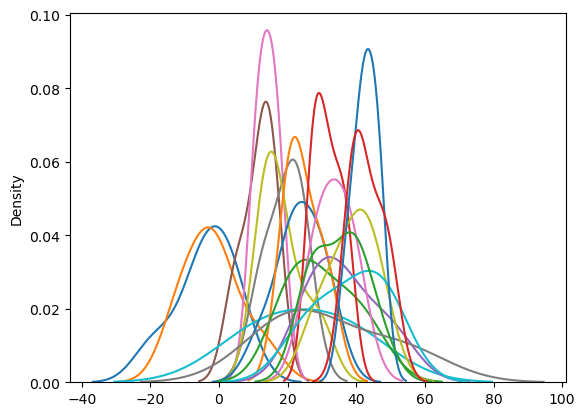

In [190]:
temps = st.temperatures
for c, temp in enumerate(temps):
    kT = unit.AVOGADRO_CONSTANT_NA * unit.BOLTZMANN_CONSTANT_kB * temp
    sts = states[c]
    kdeplot([state.getPotentialEnergy()/kT for state in sts])

In [198]:
import pandas as pd
df =pd.read_csv('./st.dat',sep='\t')

<Axes: >

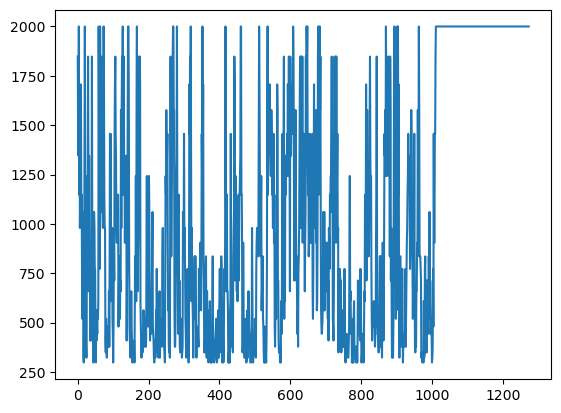

In [199]:
df['Temperature (K)'].plot()


In [193]:
probs = []
for c, temp in enumerate(st.temperatures):
    for state in states[c]:
        pe = state.getPotentialEnergy()
        logProbability = [(st._weights[i]-st.inverseTemperatures[i]*pe) for i in range(len(st._weights))]
        logProbability -= logsumexp(logProbability)
        probability = np.exp(logProbability)
        probs.append(probability[0])

In [194]:
len(probs)

150

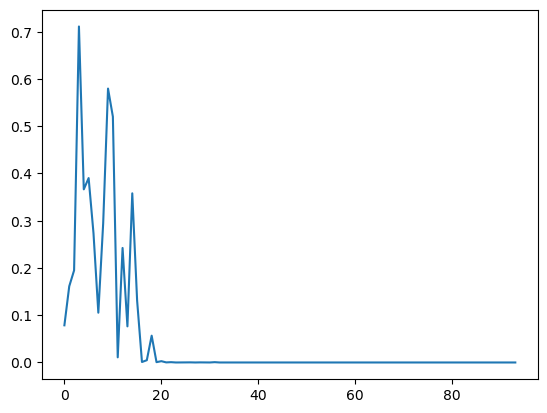

In [195]:
plt.plot(probs)

In [196]:
wts = np.array(probs)
wts/=wts.sum()

In [197]:
sampleidx = np.random.choice(
    np.arange(len(probs)),
    1000,
    p=wts)
plt.hist(sampleidx,bins=55);

ValueError: probabilities contain NaN

In [147]:
from rdkit.Chem import rdMolAlign
Chem.MolToMolFile(mol, 'ref.sdf', )
writer = Chem.SDWriter('aligned_mols.sdf')
#writer.write(mol)
mol2 = Chem.Mol(mol)

for sample in sampleidx[:100]:
    state = np.concatenate([states[c] for c in range(len(temps))])[sample]
    pos = state.getPositions(asNumpy=True).value_in_unit(unit.angstrom)

    mol2.GetConformer().SetPositions(pos)
    rdMolAlign.AlignMol(mol2, mol)
    writer.write(mol2)
    
writer.close()

In [58]:
!pwd

/Users/ljmartin/Documents/GitHub/ljmartin.github.io/notebooks


In [166]:
mol2= Chem.Mol(mol)
mol2.GetConformer().SetPositions(
    st.simulation.context.getState(getPositions=True).getPositions(asNumpy=True)._value*10
)

Chem.MolToMolFile(mol, 'ref.sdf', )
Chem.MolToMolFile(mol2, 'ref2.sdf', )